In [1]:
pip install tensorflow

/Users/All file hear/complete ai /Deep learning/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import tensorflow
from tensorflow import keras
from tensorflow.keras.layers import Dense,Flatten
from tensorflow.keras import Sequential

In [3]:
(X_train,Y_train),(X_test,Y_test)=keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [4]:
X_train.shape

(60000, 28, 28)

In [5]:
X_test.shape

(10000, 28, 28)

In [6]:
Y_train

array([5, 0, 4, ..., 5, 6, 8], shape=(60000,), dtype=uint8)

In [11]:
import matplotlib.pyplot as plt

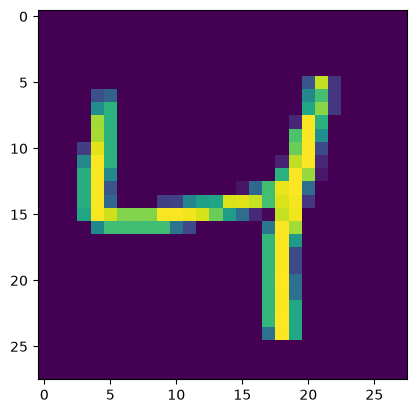

In [12]:
plt.imshow(X_train[2])

In [13]:
X_train.max()

np.uint8(255)

In [14]:
X_train = X_train/255
X_test = X_test/255

In [15]:
model = Sequential()

In [16]:
model.add(Flatten(input_shape= (28,28)))
model.add(Dense(128,activation='relu'))
model.add(Dense(10,activation="softmax"))

/Users/All file hear/complete ai /Deep learning/.venv/lib/python3.13/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
model.compile(loss='sparse_categorical_crossentropy',optimizer='Adam',metrics=['accuracy'])

In [34]:
history = model.fit(X_train,Y_train,epochs=25,validation_split=.2)

Epoch 1/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 851us/step - accuracy: 1.0000 - loss: 4.0204e-07 - val_accuracy: 0.9806 - val_loss: 0.2164
Epoch 2/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 770us/step - accuracy: 0.9985 - loss: 0.0068 - val_accuracy: 0.9766 - val_loss: 0.2556
Epoch 3/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 775us/step - accuracy: 0.9996 - loss: 0.0016 - val_accuracy: 0.9789 - val_loss: 0.2382
Epoch 4/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 838us/step - accuracy: 0.9998 - loss: 4.4354e-04 - val_accuracy: 0.9790 - val_loss: 0.2317
Epoch 5/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 816us/step - accuracy: 0.9995 - loss: 0.0018 - val_accuracy: 0.9758 - val_loss: 0.2580
Epoch 6/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 943us/step - accuracy: 0.9994 - loss: 0.0022 - val_accuracy: 0.9780 - val_loss: 0.2515
Epoch 7/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9994 - loss: 0.0025 - val_accuracy: 0.9767 - val_loss: 0.2424
Epoch 8/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 858us/step - accuracy: 0.

In [35]:
Y_pred = model.predict(X_test)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 284us/step


In [36]:
y_final=Y_pred.argmax(axis=1)
y_final

array([7, 2, 1, ..., 4, 5, 6], shape=(10000,))

In [37]:
Y_pred[0] 

array([4.1882992e-34, 0.0000000e+00, 1.2064155e-28, 6.9837712e-21,
       0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 1.0000000e+00,
       9.4855135e-33, 1.8614916e-26], dtype=float32)

In [38]:

from sklearn.metrics import accuracy_score

In [39]:
accuracy_score(Y_test,y_final)

0.9778

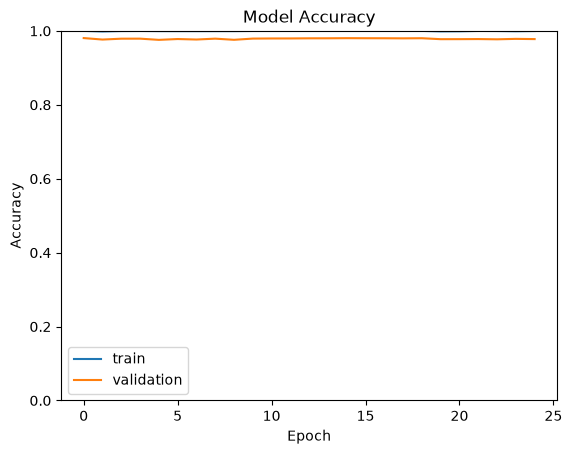

In [54]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(['train', 'validation'])
plt.ylim(0,1)

plt.show()

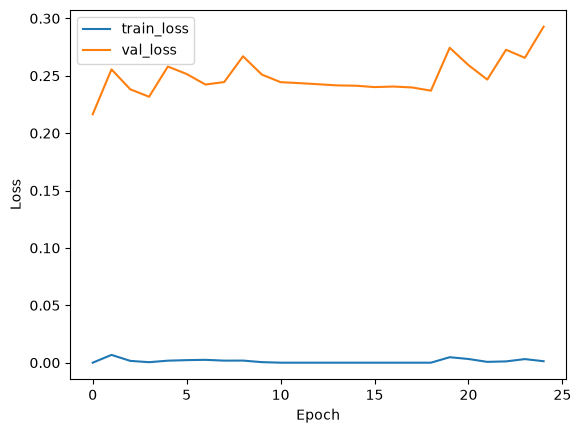

In [53]:
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()